In [3]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as an
import sys
sys.path.append('/home/jovyan/notebooks_bidossessi/Inflammatory/Remapped/autoimmuneSC/AIID_notebooks/')

from inflapy.immunoFunc import *

In [4]:
path = "/nfs/team205/bh14/Datasets/RawData/raw_and_AnnData/annDataModified/annData_Modified_complementary/"

s_path = "/nfs/team205/bh14/Datasets/Remapped/raw_adata/ummapped/"

#### Qian Yue dataset

In [5]:
adata = sc.read_h5ad(path+"Qian_Yue_Zhang_et_al_modified.h5ad")

/home/jovyan/my-conda-envs/autoimmune/lib/python3.8/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [6]:
adata

AnnData object with n_obs × n_vars = 111154 × 33694
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id'

In [5]:
adata.obs.tissue.value_counts()

Thyroid    56199
PBMC       54955
Name: tissue, dtype: int64

In [7]:
adata.obs

,tissue,disease,donor_id,dataset_id
AAACCTGAGCGTCAAG-1,PBMC,Hashimoto’s thyroiditis,HT12PBMC,Qian_Yue_Zhang_2022
AAACCTGCACAGACTT-1,PBMC,Hashimoto’s thyroiditis,HT12PBMC,Qian_Yue_Zhang_2022
AAACCTGCATGAAGTA-1,PBMC,Hashimoto’s thyroiditis,HT12PBMC,Qian_Yue_Zhang_2022
AAACCTGGTAGCACGA-1,PBMC,Hashimoto’s thyroiditis,HT12PBMC,Qian_Yue_Zhang_2022
AAACCTGGTCAGAATA-1,PBMC,Hashimoto’s thyroiditis,HT12PBMC,Qian_Yue_Zhang_2022
...,...,...,...,...
TTTGTTGGTTGCTTGA-1,Thyroid,Hashimoto’s thyroiditis,HT29Thyroid,Qian_Yue_Zhang_2022
TTTGTTGTCAGCCCAG-1,Thyroid,Hashimoto’s thyroiditis,HT29Thyroid,Qian_Yue_Zhang_2022
TTTGTTGTCGAGCCTG-1,Thyroid,Hashimoto’s thyroiditis,HT29Thyroid,Qian_Yue_Zhang_2022
TTTGTTGTCGGTCATA-1,Thyroid,Hashimoto’s thyroiditis,HT29Thyroid,Qian_Yue_Zhang_2022


In [8]:
adata.obs["cell_source"] = adata.obs["tissue"]

In [9]:
adata.obs["tissue"].replace("PBMC", "Blood", inplace=True)

In [10]:
adata.obs.disease.value_counts()

Hashimoto’s thyroiditis    111154
Name: disease, dtype: int64

In [16]:
adata

AnnData object with n_obs × n_vars = 111154 × 33694
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'cell_source'

In [15]:
gc.collect()

2920

In [11]:
temp = sc.read("/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_celltypist_scvbi_donor_as_batch.h5ad",
              backed='r')

In [12]:
temp.var_names

Index(['HES4', 'ISG15', 'TNFRSF18', 'TNFRSF4', 'MRPL20-AS1', 'PRDM16', 'PHF13',
       'RBP7', 'KIF1B', 'CDA',
       ...
       'SSR4', 'TKTL1', 'FLNA', 'MPP1', 'TMLHE', 'RPS4Y1', 'MT-CO3', 'MT-ND5',
       'AC233755.2', 'AC233755.1'],
      dtype='object', length=2000)

In [13]:
comm = [gene for gene in adata.var_names if gene in temp.var_names]

In [14]:
len(comm)

1787

#####################################################
###                      Qian_Yue_Zhang_2022.h5ad                 ###
######################################################
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.67
Detected doublet rate = 0.1%
Estimated detectable doublet fraction = 26.4%
Overall doublet rate:
	Expected   = 7.6%
	Estimated  = 0.3%
Elapsed time: 154.9 seconds


/home/jovyan/notebooks_bidossessi/Inflammatory/Remapped/autoimmuneSC/AIID_notebooks/inflapy/immunoFunc.py:363: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['doublet_scores'], adata.obs['predicted_doublets'] = scrub.scrub_doublets(min_counts=2, min_cells=3, min_gene_variability_pctl=85, n_prin_comps=30)


Pass            52306
Low_nFeature     2258
High_MT           346
Doublet            45
Name: QC, dtype: int64
Plot of metadata only for cells that pass tentative QC:  



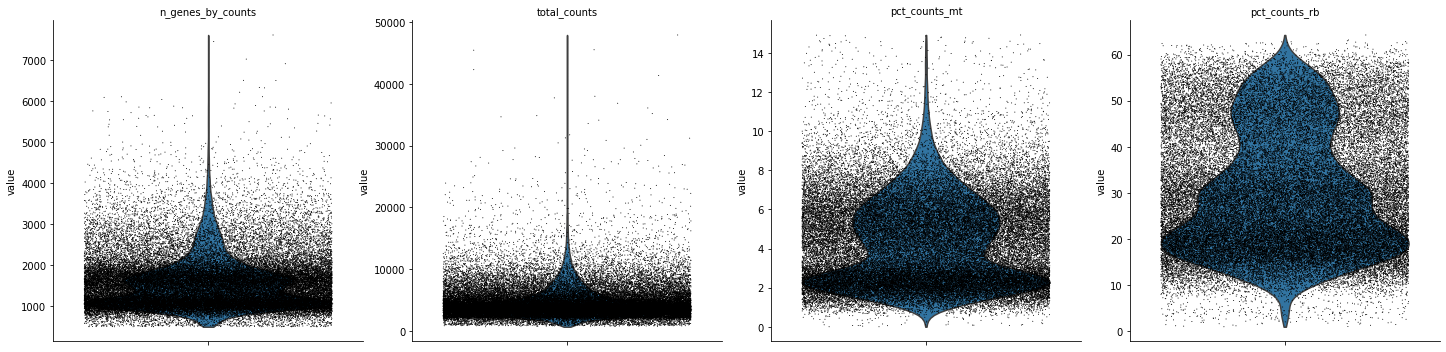

In [17]:
adataQc(adata=adata[adata.obs.tissue=="Blood"], path=s_path+"PBMC/QC_Doublet/", file="Qian_Yue_Zhang_2022.h5ad")


In [18]:
adata.obs.donor_id.value_counts()

HT28Thyroid    28084
HT29Thyroid    23683
HT28PBMC       18380
HT14PBMC       17653
HT29PBMC       15700
HT12PBMC        3222
HT13Thyroid     2685
HT12Thyroid     1747
Name: donor_id, dtype: int64

#####################################################
###                      Qian_Yue_Zhang_2022.h5ad                 ###
######################################################
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.20
Detected doublet rate = 7.1%
Estimated detectable doublet fraction = 41.7%
Overall doublet rate:
	Expected   = 7.6%
	Estimated  = 17.1%
Elapsed time: 175.1 seconds


/home/jovyan/notebooks_bidossessi/Inflammatory/Remapped/autoimmuneSC/AIID_notebooks/inflapy/immunoFunc.py:363: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['doublet_scores'], adata.obs['predicted_doublets'] = scrub.scrub_doublets(min_counts=2, min_cells=3, min_gene_variability_pctl=85, n_prin_comps=30)
/home/jovyan/my-conda-envs/autoimmune/lib/python3.8/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jovyan/my-conda-envs/autoimmune/lib/python3.8/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Pass            48022
Doublet          3996
Low_nFeature     2982
High_MT          1199
Name: QC, dtype: int64
Plot of metadata only for cells that pass tentative QC:  



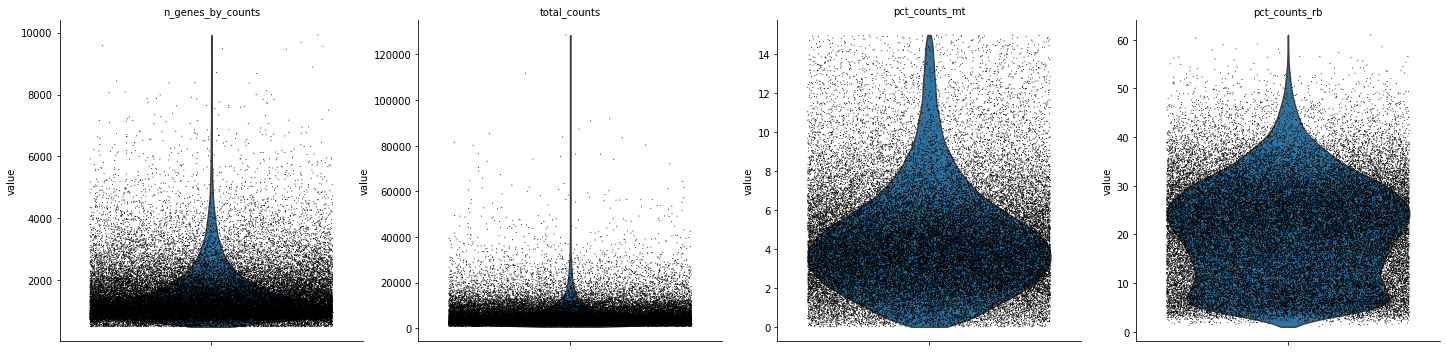

In [ ]:
adataQc(adata=adata[adata.obs.tissue!="Blood"], path=s_path+"Tissue/QC_Doublet/", file="Qian_Yue_Zhang_2022.h5ad")
